In [30]:
from pathlib import Path
import json, math
from collections import defaultdict
import numpy as np

def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def aggregate_results_by_P_kappa(dk_folder_path, results_filename="training_results.json"):
    """
    Reads `training_results.json` and aggregates by (P, kappa_0).
    NOTE: test MSE is converted to 1/2·MSE for aggregation.

    Returns a dict keyed by (P, kappa) with:
      - mean_testmse: mean of 1/2·MSE
      - errorofthemeantestmse: SEM of 1/2·MSE
      - mean_mS_final, errorofthemean_mS_final
      - n: number of runs
    """
    dk_folder_path = Path(dk_folder_path)

    # Find the results JSON
    json_path = dk_folder_path / results_filename
    if not json_path.exists():
        matches = list(dk_folder_path.rglob(results_filename))
        if not matches:
            raise FileNotFoundError(f"Could not find '{results_filename}' under {dk_folder_path}")
        json_path = matches[0]

    # Load JSON list
    with open(json_path, "r") as f:
        data = json.load(f)

    # Group values by (P, kappa)
    buckets = defaultdict(lambda: {"test_mse_half": [], "final_mS": []})

    for r in data:
        # Skip incomplete or non-trained entries robustly
        if r.get("status") and r["status"] != "trained":
            continue

        try:
            P = int(r["P"])
            kappa = float(r.get("kappa_0", r.get("kappa")))
            # Prefer already-logged half-MSE if present; otherwise scale here.
            if "test_half_mse" in r:  # optional alternative key
                test_mse_half = float(r["test_half_mse"])
            else:
                test_mse_half = 0.5 * float(r["test_mse"])
            final_mS = float(r.get("final_eval_mS", r.get("final_mS")))
        except (KeyError, TypeError, ValueError):
            continue

        if math.isnan(test_mse_half) or math.isnan(final_mS):
            continue

        buckets[(P, kappa)]["test_mse_half"].append(test_mse_half)
        buckets[(P, kappa)]["final_mS"].append(final_mS)

    # Aggregate
    out = {}
    for (P, kappa), vals in buckets.items():
        half_mse_vals = np.asarray(vals["test_mse_half"], dtype=float)
        mS_vals = np.asarray(vals["final_mS"], dtype=float)
        n = int(half_mse_vals.size)

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": float(half_mse_vals.mean()) if n else float('nan'),  # 1/2·MSE
            "errorofthemeantestmse": _sem(half_mse_vals),                        # SEM(1/2·MSE)
            "mean_mS_final": float(mS_vals.mean()) if n else float('nan'),
            "errorofthemean_mS_final": _sem(mS_vals),
            "n": n,
        }

    return out

# --- Example usage ---
results = aggregate_results_by_P_kappa("/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4")
results = aggregate_results_by_P_kappa("/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4")

from pprint import pprint; pprint(results)


{(10, 0.0005): {'P': 10,
                'errorofthemean_mS_final': 0.001176739313640449,
                'errorofthemeantestmse': 0.0462774883727483,
                'kappa': 0.0005,
                'mean_mS_final': -0.0019668275005339333,
                'mean_testmse': 0.743067721525828,
                'n': 3},
 (10, 0.001): {'P': 10,
               'errorofthemean_mS_final': 0.001644501907112309,
               'errorofthemeantestmse': 0.04549105561866646,
               'kappa': 0.001,
               'mean_mS_final': 0.0018823574452350538,
               'mean_testmse': 0.7423081199328104,
               'n': 3},
 (10, 0.005): {'P': 10,
               'errorofthemean_mS_final': 0.0011978777480011352,
               'errorofthemeantestmse': 0.023684381856883773,
               'kappa': 0.005,
               'mean_mS_final': -0.0012788284244985941,
               'mean_testmse': 0.7661254604657491,
               'n': 3},
 (10, 0.0075): {'P': 10,
                'errorofthemean_mS_

ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

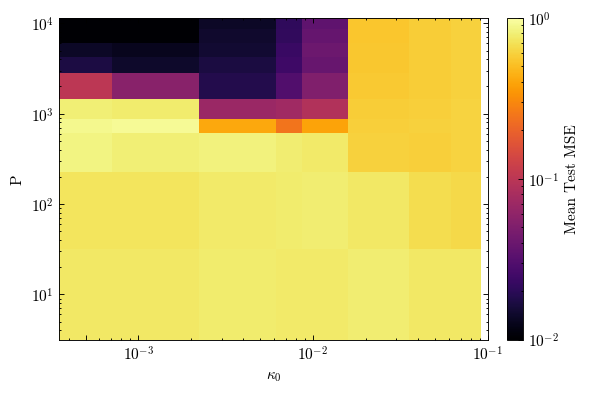

In [31]:
# --- Flexible heatmap from aggregated dictionary (ticks + logs + cmap + cbar) ---
from pathlib import Path
import sys
import math
from typing import Optional, Tuple, Sequence
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

PLOT_UTILS_DIR = "/home/goring/mean_field_langevin/plots_utils"  # where slim_plotters.py lives

def _apply_slim_style(theme: str = "light", serif: bool = True) -> None:
    """Try to apply your SLIM plotting style; fall back silently if missing."""
    try:
        if PLOT_UTILS_DIR not in sys.path:
            sys.path.insert(0, PLOT_UTILS_DIR)
        from slim_plotters import apply  # type: ignore
        apply(theme=theme, serif=serif)
    except Exception as e:
        print(f"[note] slim_plotters not applied ({e}); using Matplotlib defaults.)")

def _edges_from_centers(centers: np.ndarray, log: bool = False) -> np.ndarray:
    """Compute pixel edges from sorted center coordinates (linear or log)."""
    centers = np.asarray(centers, dtype=float)
    centers = np.sort(centers)
    n = centers.size
    if n == 1:
        c = centers[0]
        if log and c > 0:
            return np.array([c/np.sqrt(10.0), c*np.sqrt(10.0)])
        delta = 0.5 if c == 0 else 0.5 * abs(c)
        return np.array([c - delta, c + delta])

    if log and np.any(centers <= 0):
        log = False  # can't do log edges with nonpositive centers

    edges = np.empty(n + 1, dtype=float)
    if log:
        mids = np.sqrt(centers[:-1] * centers[1:])
        edges[1:-1] = mids
        r0 = centers[1] / centers[0]
        r1 = centers[-1] / centers[-2]
        edges[0] = centers[0] / np.sqrt(r0)
        edges[-1] = centers[-1] * np.sqrt(r1)
    else:
        mids = 0.5 * (centers[:-1] + centers[1:])
        edges[1:-1] = mids
        edges[0]  = centers[0] - (mids[0] - centers[0])
        edges[-1] = centers[-1] + (centers[-1] - mids[-1])
    return edges

def heatmap_from_agg_dict(
    agg_dict: dict,
    *,
    value_key: str = "mean_testmse",     # e.g. "mean_train_error", "mean_testmse", ...
    cmap: str = "viridis",
    figsize: Tuple[float, float] = (4.0, 3.0),
    aspect: str = "auto",                # "auto", "equal", or a numeric aspect
    xlog: bool = False,
    ylog: bool = False,
    clog: bool = False,                  # log color scale
    vmin: Optional[float] = None,        # explicit colorbar min
    vmax: Optional[float] = None,        # explicit colorbar max
    clabel: Optional[str] = None,        # custom colorbar label
    sort_P_ascending: bool = True,
    sort_kappa_ascending: bool = True,
    xticks: Optional[Sequence[float]] = None,      # explicit x tick positions (kappa)
    yticks: Optional[Sequence[float]] = None,      # explicit y tick positions (P)
    xtick_labels: Optional[Sequence[str]] = None,  # optional custom labels (len must match xticks)
    ytick_labels: Optional[Sequence[str]] = None,  # optional custom labels (len must match yticks)
    save_path: Optional[str] = None,
    theme: str = "light",
    serif: bool = True,
):
    """
    Build a heatmap from an aggregated dict. X = kappa, Y = P, cell = agg[value_key].

    - True log axes support (xlog/ylog) and optional log colorbar (clog).
    - Explicit colorbar range via vmin/vmax; for clog=True, vmin must be > 0.
    - No title or cell annotations; no gridlines inside the plot.
    - Explicit tick selection: pass xticks=[...], yticks=[...]. If labels provided,
      uses them; otherwise auto-formats.
    """
    _apply_slim_style(theme=theme, serif=serif)

    # Collect (P, kappa, value)
    records = []
    for k, v in agg_dict.items():
        if isinstance(k, tuple) and len(k) == 2:
            P, kappa = k
        else:
            P = v.get("P")
            kappa = v.get("kappa")
        if P is None or kappa is None or value_key not in v:
            continue
        try:
            P = int(P); kappa = float(kappa); val = float(v[value_key])
        except (TypeError, ValueError):
            continue
        if math.isnan(val):
            continue
        records.append((P, kappa, val))

    if not records:
        raise ValueError(f"No usable entries for value_key='{value_key}'.")

    # Unique sorted axes
    Ps = sorted({r[0] for r in records}, reverse=not sort_P_ascending)
    kappas = sorted({r[1] for r in records}, reverse=not sort_kappa_ascending)

    # Build Z with running means in case of duplicates
    Z = np.full((len(Ps), len(kappas)), np.nan, dtype=float)
    counts = np.zeros_like(Z, dtype=int)
    p_index = {p: i for i, p in enumerate(Ps)}
    k_index = {k0: j for j, k0 in enumerate(kappas)}
    for P, k0, val in records:
        i = p_index[P]; j = k_index[k0]
        if np.isnan(Z[i, j]):
            Z[i, j] = val; counts[i, j] = 1
        else:
            Z[i, j] = (Z[i, j] * counts[i, j] + val) / (counts[i, j] + 1)
            counts[i, j] += 1

    # Axis centers and edges
    xcenters = np.asarray(kappas, dtype=float)
    ycenters = np.asarray(Ps, dtype=float)
    xedges = _edges_from_centers(xcenters, log=xlog)
    yedges = _edges_from_centers(ycenters, log=ylog)

    # Color normalization
    Zmask = np.ma.masked_invalid(Z)
    if clog:
        if vmin is not None and vmin <= 0:
            raise ValueError("For clog=True, vmin must be > 0.")
        # LogNorm needs strictly positive vmin
        if vmin is None:
            positive = np.asarray(Zmask.compressed())
            positive = positive[positive > 0]
            if positive.size == 0:
                raise ValueError("clog=True but all values are <= 0 or NaN.")
            vmin_use = float(positive.min())
        else:
            vmin_use = float(vmin)
        vmax_use = float(np.nanmax(Z)) if vmax is None else float(vmax)
        norm = LogNorm(vmin=vmin_use, vmax=vmax_use)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Draw
    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(xedges, yedges, Zmask, cmap=cmap, norm=norm, shading="auto")
    cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(clabel if clabel is not None else value_key, labelpad=4)

    # Axes config
    if xlog: ax.set_xscale("log")
    if ylog: ax.set_yscale("log")
    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel("P")
    ax.set_aspect(aspect)

    # Remove any gridlines (both major/minor)
    ax.grid(False)

    # Ticks: use explicit ticks if provided, else centers
    def _fmt_kappa(x: float) -> str:
        return f"{x:.2g}" if (abs(x) < 1e-2 or abs(x) >= 1e2) else f"{x:g}"

    # X ticks (kappa)
    if xticks is None:
        xt = xcenters
        xlabels = [_fmt_kappa(x) for x in xcenters]
    else:
        xt = np.asarray(list(xticks), dtype=float)
        if xlog:
            xt = xt[xt > 0]  # drop nonpositive for log scale
        xlabels = (
            list(xtick_labels) if xtick_labels is not None
            else [_fmt_kappa(x) for x in xt]
        )
    ax.set_xticks(xt)
    ax.set_xticklabels(xlabels)

    # Y ticks (P)
    if yticks is None:
        yt = ycenters
        ylabels = [str(int(y)) for y in ycenters]
    else:
        yt = np.asarray(list(yticks), dtype=float)
        if ylog:
            yt = yt[yt > 0]
        ylabels = (
            list(ytick_labels) if ytick_labels is not None
            else [str(int(y)) for y in yt]
        )
    ax.set_yticks(yt)
    ax.set_yticklabels(ylabels)

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[saved] {save_path}")

    return fig, ax, {"Z": Z, "Ps": Ps, "kappas": kappas, "counts": counts}


fig, ax, meta = heatmap_from_agg_dict(
    results,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10", "10000"],
)
plt.show()


In [27]:
# --- Flexible heatmap with smoothing options (upsample/gouraud) ------------
from pathlib import Path
import sys
import math
from typing import Optional, Tuple, Sequence, Union
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

PLOT_UTILS_DIR = "/home/goring/mean_field_langevin/plots_utils"  # where slim_plotters.py lives

def _apply_slim_style(theme: str = "light", serif: bool = True) -> None:
    """Try to apply your SLIM plotting style; fall back silently if missing."""
    try:
        if PLOT_UTILS_DIR not in sys.path:
            sys.path.insert(0, PLOT_UTILS_DIR)
        from slim_plotters import apply  # type: ignore
        apply(theme=theme, serif=serif)
    except Exception as e:
        print(f"[note] slim_plotters not applied ({e}); using Matplotlib defaults.)")

def _edges_from_centers(centers: np.ndarray, log: bool = False) -> np.ndarray:
    """Compute pixel edges from sorted center coordinates (linear or log)."""
    centers = np.asarray(centers, dtype=float)
    centers = np.sort(centers)
    n = centers.size
    if n == 1:
        c = centers[0]
        if log and c > 0:
            return np.array([c/np.sqrt(10.0), c*np.sqrt(10.0)])
        delta = 0.5 if c == 0 else 0.5 * abs(c)
        return np.array([c - delta, c + delta])

    if log and np.any(centers <= 0):
        log = False  # can't do log edges with nonpositive centers

    edges = np.empty(n + 1, dtype=float)
    if log:
        mids = np.sqrt(centers[:-1] * centers[1:])
        edges[1:-1] = mids
        r0 = centers[1] / centers[0]
        r1 = centers[-1] / centers[-2]
        edges[0] = centers[0] / np.sqrt(r0)
        edges[-1] = centers[-1] * np.sqrt(r1)
    else:
        mids = 0.5 * (centers[:-1] + centers[1:])
        edges[1:-1] = mids
        edges[0]  = centers[0] - (mids[0] - centers[0])
        edges[-1] = centers[-1] + (centers[-1] - mids[-1])
    return edges

def _bilinear_upsample(
    Z: np.ndarray,
    xcenters: np.ndarray,
    ycenters: np.ndarray,
    refine: Union[int, Tuple[int, int]],
    xlog: bool,
    ylog: bool,
):
    """
    Upsample Z defined on a rectangular grid of centers (y, x) via separable 1D linear
    interpolation along x then y. Interpolates in log-coordinates if xlog/ylog True.
    """
    Z = np.asarray(Z, dtype=float)
    ycenters = np.asarray(ycenters, dtype=float)
    xcenters = np.asarray(xcenters, dtype=float)

    if isinstance(refine, int):
        ry = rx = max(1, int(refine))
    else:
        ry = max(1, int(refine[0])); rx = max(1, int(refine[1]))

    # Coordinates for interpolation (in axis space where spacing is uniform)
    xcoord = np.log(xcenters) if xlog else xcenters
    ycoord = np.log(ycenters) if ylog else ycenters

    # New, denser coordinates across the same span
    x_new = np.linspace(xcoord.min(), xcoord.max(), num=Z.shape[1] * rx)
    y_new = np.linspace(ycoord.min(), ycoord.max(), num=Z.shape[0] * ry)

    # Interpolate along x for each row
    Zx = np.empty((Z.shape[0], x_new.size), dtype=float)
    for i in range(Z.shape[0]):
        Zx[i, :] = np.interp(x_new, xcoord, Z[i, :])

    # Interpolate along y for each column
    Zxy = np.empty((y_new.size, x_new.size), dtype=float)
    for j in range(Zx.shape[1]):
        Zxy[:, j] = np.interp(y_new, ycoord, Zx[:, j])

    # Map coordinates back to original axis scale
    xcent_new = np.exp(x_new) if xlog else x_new
    ycent_new = np.exp(y_new) if ylog else y_new

    return Zxy, xcent_new, ycent_new

def _cell_to_vertex_values(Z: np.ndarray) -> np.ndarray:
    """
    Convert cell-centered (Ny, Nx) values to vertex-centered (Ny+1, Nx+1)
    by averaging adjacent cells (edges/corners handled with available neighbors).
    Useful for Gouraud shading (vertex colors).
    """
    Ny, Nx = Z.shape
    V = np.empty((Ny + 1, Nx + 1), dtype=float)

    # interior
    V[1:Ny, 1:Nx] = 0.25 * (Z[:-1, :-1] + Z[1:, :-1] + Z[:-1, 1:] + Z[1:, 1:])

    # edges
    V[0, 1:Nx]      = 0.5 * (Z[0, :-1] + Z[0, 1:])            # top edge (between first row cells)
    V[Ny, 1:Nx]     = 0.5 * (Z[-1, :-1] + Z[-1, 1:])          # bottom edge
    V[1:Ny, 0]      = 0.5 * (Z[:-1, 0] + Z[1:, 0])            # left edge
    V[1:Ny, Nx]     = 0.5 * (Z[:-1, -1] + Z[1:, -1])          # right edge

    # corners
    V[0, 0]         = Z[0, 0]
    V[0, Nx]        = Z[0, -1]
    V[Ny, 0]        = Z[-1, 0]
    V[Ny, Nx]       = Z[-1, -1]

    return V

def heatmap_from_agg_dict(
    agg_dict: dict,
    *,
    value_key: str = "mean_testmse",     # e.g. "mean_train_error", "mean_testmse", ...
    cmap: str = "viridis",
    figsize: Tuple[float, float] = (4.8, 3.6),
    aspect: Union[str, float] = "auto",  # "auto", "equal", or numeric
    xlog: bool = False,
    ylog: bool = False,
    clog: bool = False,                  # log color scale
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    sort_P_ascending: bool = True,
    sort_kappa_ascending: bool = True,
    xticks: Optional[Sequence[float]] = None,      # explicit x tick positions (kappa)
    yticks: Optional[Sequence[float]] = None,      # explicit y tick positions (P)
    xtick_labels: Optional[Sequence[str]] = None,  # optional custom labels
    ytick_labels: Optional[Sequence[str]] = None,  # optional custom labels
    smooth: str = "none",                           # "none", "upsample", "gouraud"
    refine: Union[int, Tuple[int, int]] = 4,       # only used for "upsample"
    save_path: Optional[str] = None,
    theme: str = "light",
    serif: bool = True,
):
    """
    Build a heatmap from an aggregated dict. X = kappa, Y = P, cell = agg[value_key].

    Smoothing options:
      - smooth="none"     : original blocky heatmap
      - smooth="upsample" : bilinear upsampling (control smoothness via `refine`)
      - smooth="gouraud"  : Gouraud vertex shading (no `refine` needed)

    All log scales supported (x/y/colour). No internal gridlines, no title, no cell labels.
    """
    _apply_slim_style(theme=theme, serif=serif)

    # Collect (P, kappa, value)
    records = []
    for k, v in agg_dict.items():
        if isinstance(k, tuple) and len(k) == 2:
            P, kappa = k
        else:
            P = v.get("P")
            kappa = v.get("kappa")
        if P is None or kappa is None or value_key not in v:
            continue
        try:
            P = int(P); kappa = float(kappa); val = float(v[value_key])
        except (TypeError, ValueError):
            continue
        if math.isnan(val):
            continue
        records.append((P, kappa, val))

    if not records:
        raise ValueError(f"No usable entries for value_key='{value_key}'.")

    # Unique sorted axes
    Ps = sorted({r[0] for r in records}, reverse=not sort_P_ascending)
    kappas = sorted({r[1] for r in records}, reverse=not sort_kappa_ascending)

    # Build Z with running means in case of duplicates
    Z = np.full((len(Ps), len(kappas)), np.nan, dtype=float)
    counts = np.zeros_like(Z, dtype=int)
    p_index = {p: i for i, p in enumerate(Ps)}
    k_index = {k0: j for j, k0 in enumerate(kappas)}
    for P, k0, val in records:
        i = p_index[P]; j = k_index[k0]
        if np.isnan(Z[i, j]):
            Z[i, j] = val; counts[i, j] = 1
        else:
            Z[i, j] = (Z[i, j] * counts[i, j] + val) / (counts[i, j] + 1)
            counts[i, j] += 1

    # Axis centers (as actual coordinates)
    xcenters = np.asarray(kappas, dtype=float)
    ycenters = np.asarray(Ps, dtype=float)

    # Optional smoothing
    method = smooth.lower().strip()
    if method == "upsample":
        Zplot, xcent_plot, ycent_plot = _bilinear_upsample(
            Z, xcenters, ycenters, refine=refine, xlog=xlog, ylog=ylog
        )
        xedges = _edges_from_centers(xcent_plot, log=xlog)
        yedges = _edges_from_centers(ycent_plot, log=ylog)
        C_for_plot = np.ma.masked_invalid(Zplot)
        use_gouraud = False
        Xmesh = Ymesh = None
    elif method == "gouraud":
        # Need vertex coordinates and vertex colors
        xedges = _edges_from_centers(xcenters, log=xlog)
        yedges = _edges_from_centers(ycenters, log=ylog)
        Xmesh, Ymesh = np.meshgrid(xedges, yedges)
        C_for_plot = _cell_to_vertex_values(Z)  # (Ny+1, Nx+1)
        use_gouraud = True
    else:  # "none"
        xedges = _edges_from_centers(xcenters, log=xlog)
        yedges = _edges_from_centers(ycenters, log=ylog)
        C_for_plot = np.ma.masked_invalid(Z)
        use_gouraud = False
        Xmesh = Ymesh = None

    # Color normalization
    if clog:
        # LogNorm needs strictly positive vmin
        if vmin is None:
            flat = np.asarray(C_for_plot).ravel()
            positive = flat[np.isfinite(flat) & (flat > 0)]
            if positive.size == 0:
                raise ValueError("clog=True but all values are <= 0 or NaN.")
            vmin_use = float(positive.min())
        else:
            vmin_use = float(vmin)
        if vmax is None:
            vmax_use = float(np.nanmax(C_for_plot))
        else:
            vmax_use = float(vmax)
        norm = LogNorm(vmin=vmin_use, vmax=vmax_use)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    if use_gouraud:
        # Gouraud requires 2D X,Y,C with same shape
        mesh = ax.pcolormesh(Xmesh, Ymesh, C_for_plot, cmap=cmap, norm=norm, shading="gouraud")
    else:
        mesh = ax.pcolormesh(xedges, yedges, C_for_plot, cmap=cmap, norm=norm, shading="auto")
    cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(value_key, labelpad=4)

    # Axes config
    if xlog: ax.set_xscale("log")
    if ylog: ax.set_yscale("log")
    ax.set_xlabel(r"$\kappa_0$")
    ax.set_ylabel("P")
    ax.set_aspect(aspect)

    # Remove any gridlines
    ax.grid(False)

    # Ticks: explicit if provided, otherwise use centers
    def _fmt_kappa(x: float) -> str:
        return f"{x:.2g}" if (abs(x) < 1e-2 or abs(x) >= 1e2) else f"{x:g}"

    # X ticks (kappa)
    if xticks is None:
        xt = xcenters
        xlabels = [_fmt_kappa(x) for x in xcenters]
    else:
        xt = np.asarray(list(xticks), dtype=float)
        if xlog: xt = xt[xt > 0]
        xlabels = list(xtick_labels) if xtick_labels is not None else [_fmt_kappa(x) for x in xt]
    ax.set_xticks(xt)
    ax.set_xticklabels(xlabels)

    # Y ticks (P)
    if yticks is None:
        yt = ycenters
        ylabels = [str(int(y)) for y in ycenters]
    else:
        yt = np.asarray(list(yticks), dtype=float)
        if ylog: yt = yt[yt > 0]
        ylabels = list(ytick_labels) if ytick_labels is not None else [str(int(y)) for y in yt]
    ax.set_yticks(yt)
    ax.set_yticklabels(ylabels)

    plt.tight_layout()

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"[saved] {save_path}")

    return fig, ax, {
        "Z": Z, "Ps": Ps, "kappas": kappas, "counts": counts,
        "method": method, "refine": refine
    }


In [57]:
fig, ax, meta = heatmap_from_agg_dict(
    results,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(7.0, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    smooth="upsample", refine=18,     # try 2, 4, 6, 8...
    xticks=[5e-4, 7.5e-3], yticks=[10, 10000],
)
plt.show()


TypeError: heatmap_from_agg_dict() got an unexpected keyword argument 'smooth'

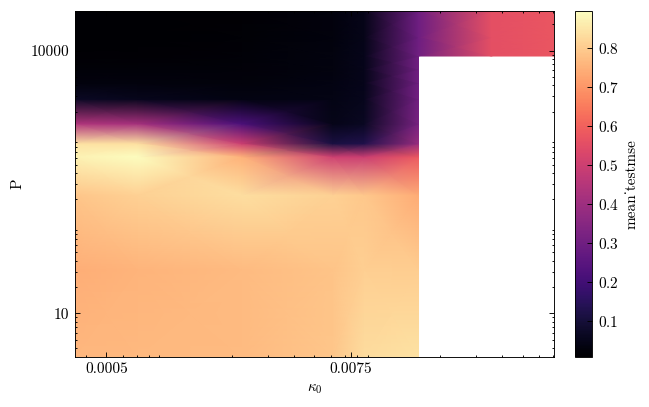

In [18]:
fig, ax, meta = heatmap_from_agg_dict(
    results,
    value_key="mean_testmse",
    cmap="magma",
    figsize=(6.0, 3.8),
    xlog=True, ylog=True, clog=False,
    smooth="gouraud",
    xticks=[5e-4, 7.5e-3], yticks=[10, 10000],
)
plt.show()


## experiment


In [3]:
from pathlib import Path
import json, math, re
from collections import defaultdict
import numpy as np

def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def _safe_float(x, default=float('nan')):
    try:
        return float(x)
    except Exception:
        return default

def _parse_P_kappa_from_filename(name: str):
    """
    Extract P and kappa from filenames like:
      rs_aw_..._P10000_kap1.000e-01_..._Ptr10000_..._kap7.500e-02_...
    Priority:
      1) Ptr{P}
      2) first standalone _P{int}_ (not Peval)
      3) first kap{number}
    """
    P = None
    m_ptr = re.search(r'Ptr(\d+)', name)
    if m_ptr:
        P = int(m_ptr.group(1))
    else:
        m_p = re.search(r'(?<!Peval)(?:^|_)P(\d+)(?=_)', name)
        if m_p:
            P = int(m_p.group(1))

    kappa = float('nan')
    m_k = re.search(r'kap([+\-]?\d*\.?\d+(?:[eE][+\-]?\d+)?)', name)
    if m_k:
        kappa = _safe_float(m_k.group(1))
    return P, kappa

def _final_half_mse_from_traj(traj: dict):
    """
    Prefer traj['half_mse_empirical'] last (already 1/2·MSE on held-out).
    Fallbacks: half_mse_total_ms, mean(last half_mse_empirical_per_exp), and
    finally 0.5 * last train_mse.
    """
    def last_of(x):
        if isinstance(x, list) and x:
            return x[-1]
        return x

    v = last_of(traj.get('half_mse_empirical'))
    if isinstance(v, (float, int)):
        return float(v)

    v = last_of(traj.get('half_mse_total_ms'))
    if isinstance(v, (float, int)):
        return float(v)

    per_exp = traj.get('half_mse_empirical_per_exp')
    if isinstance(per_exp, list) and per_exp:
        last = per_exp[-1]
        try:
            arr = np.asarray(last, dtype=float)
            if arr.size:
                return float(np.mean(arr))
        except Exception:
            pass

    tm = last_of(traj.get('train_mse'))
    if isinstance(tm, (float, int)):
        return 0.5 * float(tm)  # ensure HALF MSE units

    return float('nan')

def _final_mS_scalar_from_traj(traj: dict):
    """
    'm_S' last entry; average across modes if it's a list.
    """
    mS_hist = traj.get('m_S')
    if not isinstance(mS_hist, list) or not mS_hist:
        return float('nan')
    last = mS_hist[-1]
    if isinstance(last, (float, int)):
        return float(last)
    try:
        arr = np.asarray(last, dtype=float)
        if arr.size:
            return float(np.mean(arr))
    except Exception:
        pass
    return float('nan')

def _fill_nan_one(x):
    try:
        xf = float(x)
        if math.isnan(xf) or math.isinf(xf):
            return 1.0
        return xf
    except Exception:
        # if it wasn't a float, just return as-is
        return x

def aggregate_rs_results_by_P_kappa(root_dir, filename_glob="**/*.json"):
    """
    Walks `root_dir` recursively, loads run JSONs from the RS cavity script,
    aggregates by (P, kappa), and replaces any NaN/inf outputs with 1.0.
    """
    root = Path(root_dir)
    files = list(root.glob(filename_glob))

    buckets = defaultdict(lambda: {"half_mse": [], "mS": []})

    for fp in files:
        if not fp.name.endswith(".json"):
            continue
        try:
            with open(fp, "r") as f:
                payload = json.load(f)
        except Exception:
            continue

        traj = payload.get("traj", {})
        cfg = payload.get("config", {})

        # kappa: prefer config, else filename
        kappa = _safe_float(cfg.get("kappa"))
        P, kappa_from_name = _parse_P_kappa_from_filename(fp.name)
        if math.isnan(kappa) or not isinstance(kappa, float):
            kappa = kappa_from_name

        if P is None or (kappa is None) or math.isnan(float(kappa)):
            continue

        half_mse = _final_half_mse_from_traj(traj)
        mS = _final_mS_scalar_from_traj(traj)

        if not math.isnan(half_mse):
            buckets[(P, float(kappa))]["half_mse"].append(float(half_mse))
        if not math.isnan(mS):
            buckets[(P, float(kappa))]["mS"].append(float(mS))

    out = {}
    for (P, kappa), vals in buckets.items():
        half_mse_vals = np.asarray(vals["half_mse"], dtype=float)
        mS_vals = np.asarray(vals["mS"], dtype=float)

        n = int(half_mse_vals.size)  # n is based on half_mse count

        mean_half = float(half_mse_vals.mean()) if n else float('nan')
        sem_half = _sem(half_mse_vals) if n else float('nan')

        # mS could be missing even if half_mse exists
        if mS_vals.size:
            mean_mS = float(mS_vals.mean())
            sem_mS = _sem(mS_vals)
        else:
            mean_mS = float('nan')
            sem_mS = float('nan')

        # Replace NaN/inf with 1.0 as requested
        mean_half = _fill_nan_one(mean_half)
        sem_half = _fill_nan_one(sem_half)
        mean_mS = _fill_nan_one(mean_mS)
        sem_mS = _fill_nan_one(sem_mS)

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": mean_half,                 # already 1/2·MSE
            "errorofthemeantestmse": sem_half,         # SEM(1/2·MSE)
            "mean_mS_final": mean_mS,
            "errorofthemean_mS_final": sem_mS,
            "n": n,
        }

    return out

# --- Example usage ---
if __name__ == "__main__":
    results2 = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm"
    )
    results2 = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_new/alltest"
    )
    results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_10/ard_1.0gd")
    from pprint import pprint
    pprint(results2)


{(10, 0.001): {'P': 10,
               'errorofthemean_mS_final': 1.0,
               'errorofthemeantestmse': 1.0,
               'kappa': 0.001,
               'mean_mS_final': -0.0016168182094891865,
               'mean_testmse': 0.9228052124381065,
               'n': 1},
 (10, 0.005): {'P': 10,
               'errorofthemean_mS_final': 1.0,
               'errorofthemeantestmse': 1.0,
               'kappa': 0.005,
               'mean_mS_final': 0.0005720044415890394,
               'mean_testmse': 0.6946138803917469,
               'n': 1},
 (10, 0.0075): {'P': 10,
                'errorofthemean_mS_final': 1.0,
                'errorofthemeantestmse': 1.0,
                'kappa': 0.0075,
                'mean_mS_final': 0.00034860273626691196,
                'mean_testmse': 0.695509076114225,
                'n': 1},
 (10, 0.01): {'P': 10,
              'errorofthemean_mS_final': 1.0,
              'errorofthemeantestmse': 1.0,
              'kappa': 0.01,
              'mea

ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

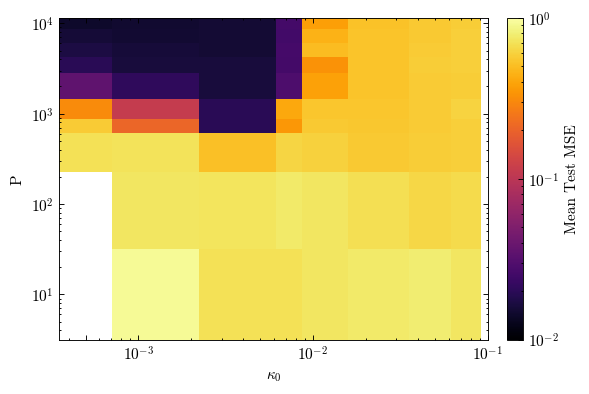

In [128]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_10/ard_1.0gd")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

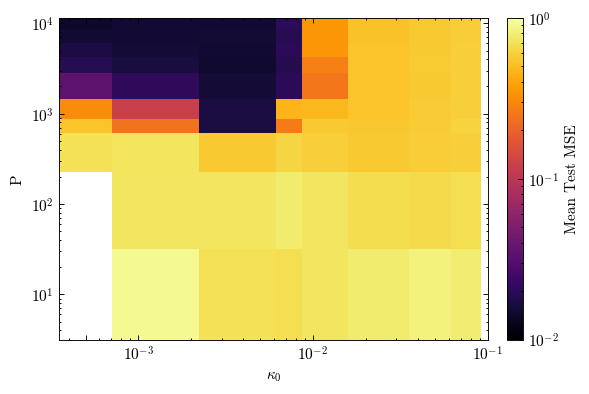

In [16]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_0.1/ard_0.1gd")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

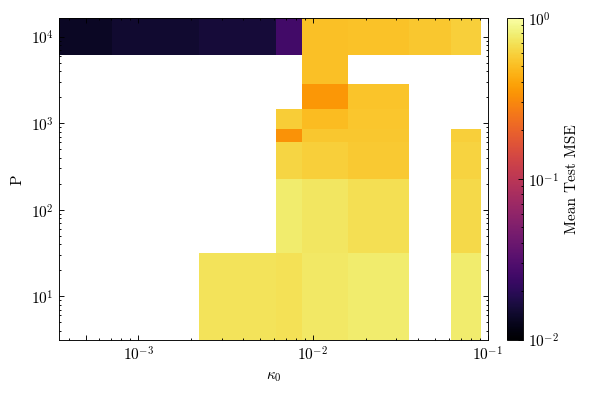

In [15]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_1.0true/ard_1.0gd_true")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

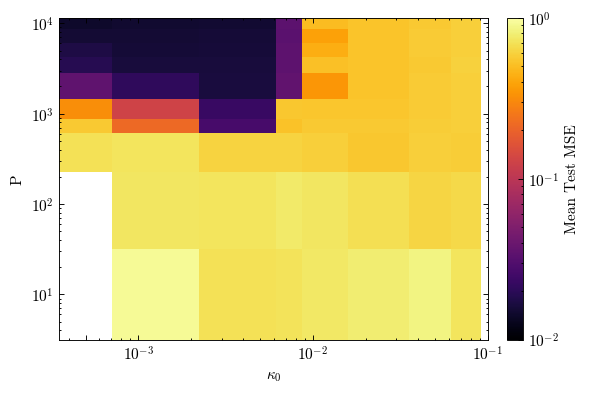

In [125]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_3.0true/ard_3.0gd")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

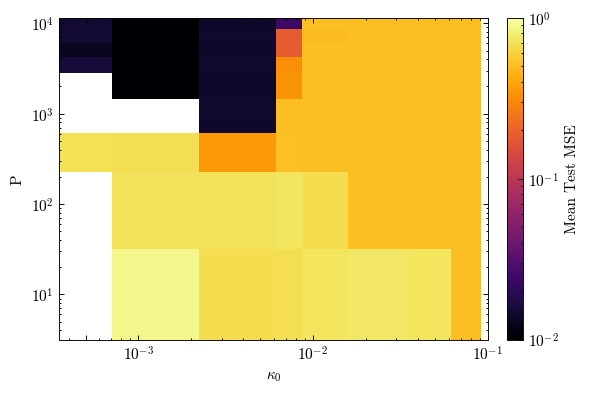

In [7]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_1.0true/ard_1.0gd_nonoise")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

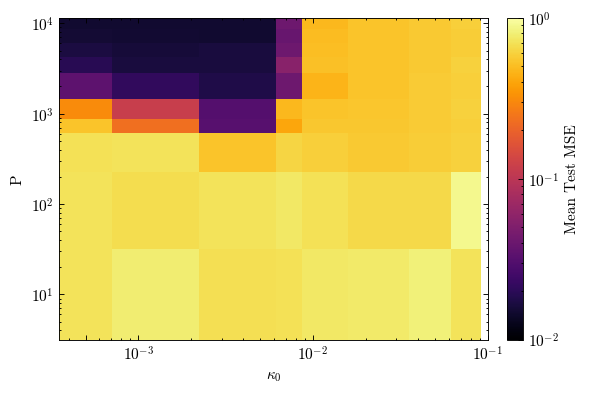

In [6]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_final/ard_5.0gd_nolinear")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

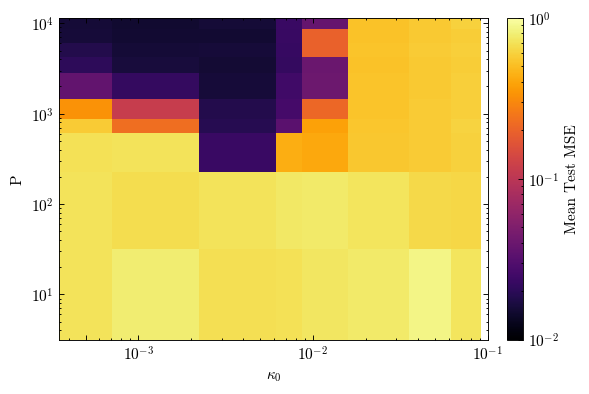

In [26]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_final/ard_5.0gd_linear")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

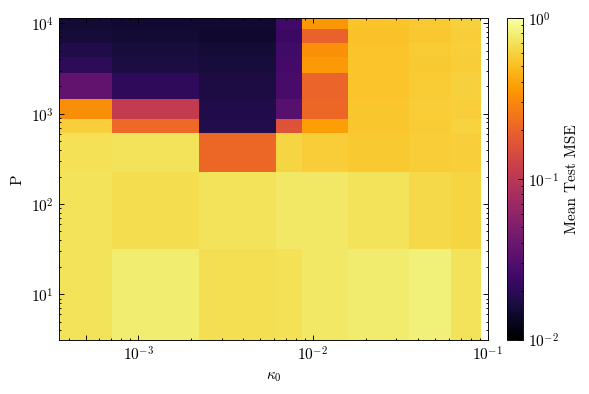

In [14]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_final/ard_12.0gd_linear")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

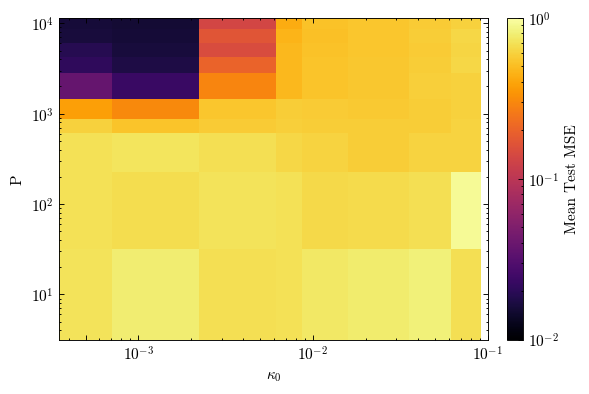

In [5]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_final/ard_50gd_nolinear")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

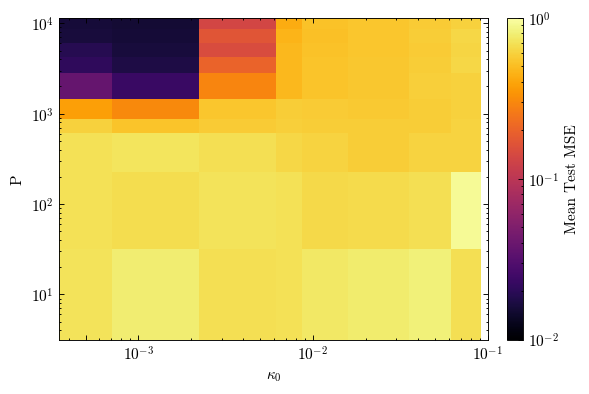

In [8]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_final/ard_50gd_nolinear")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

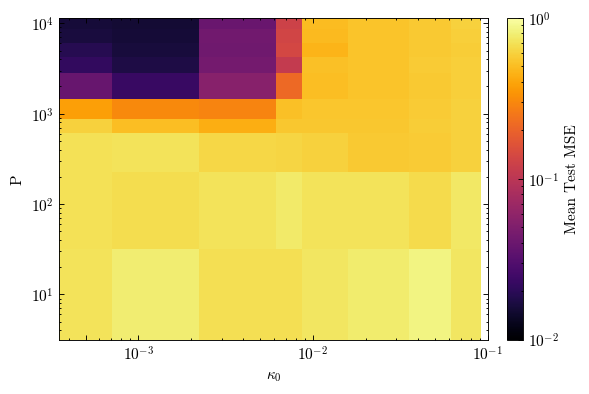

In [13]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_final/ard_50.0gd_linear")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

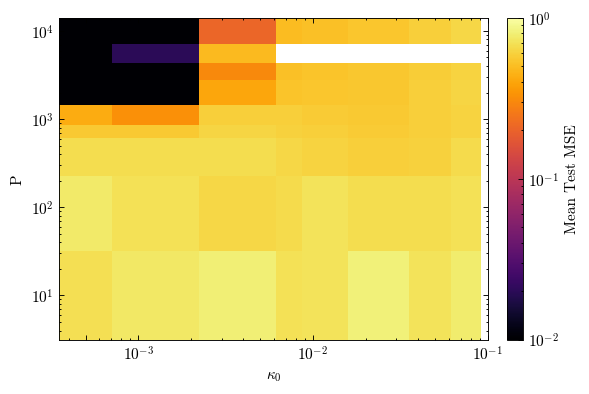

In [12]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper1/ard_1_inner5")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

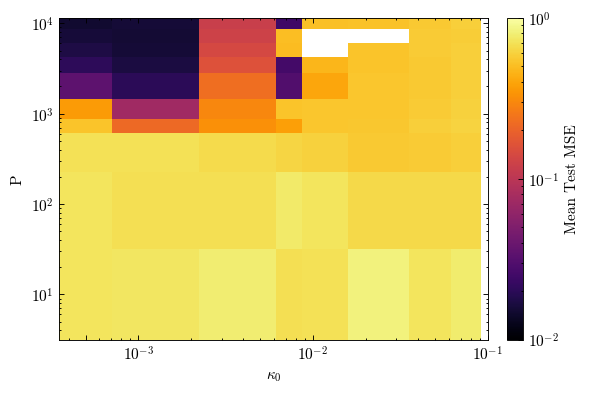

In [17]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper1/ard_1_inner100_first_1e-7")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

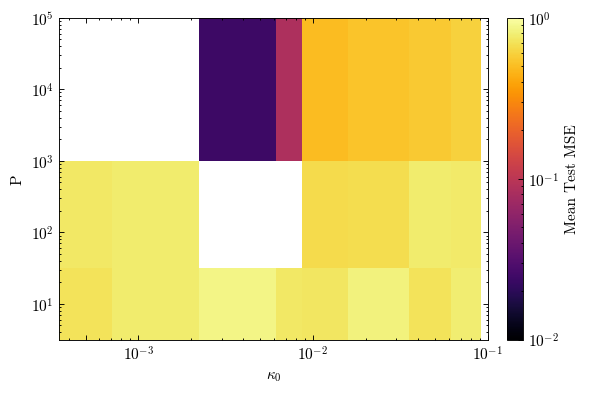

In [10]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper1/ard_5_inner200_7e-8")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (2).

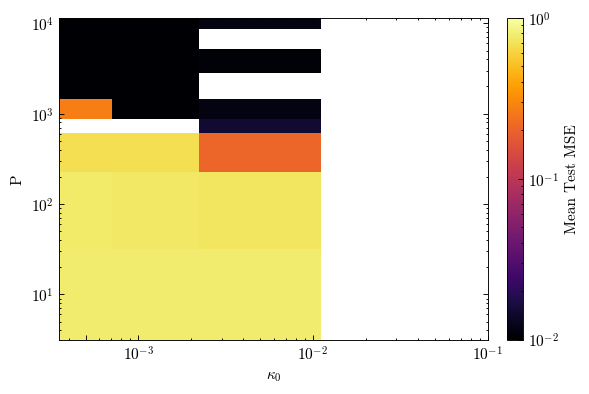

In [27]:
results2 = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final1")

fig, ax, meta = heatmap_from_agg_dict(
    results2,
    value_key="mean_testmse",
    cmap="inferno",
    figsize=(5.5, 3.8),
    aspect="auto",
    xlog=True, ylog=True, clog=True,
    vmin=1e-2,            # <-- colorbar minimum
    vmax=1,            # <-- colorbar maximum
    clabel="Mean Test MSE",
    xticks=[5e-4, 1e-3,1e-2,1e-1],
    yticks=[10,100,1000,5000,10000],
    xtick_labels=["5e-4", "7.5e-3"],
    ytick_labels=["10^1","100","1000","5000","10000"],
)
plt.show()